In [1]:

import os
from torch.utils.data import Dataset
import cv2
import PIL
from PIL import Image
import pickle
import numpy as np
import torch
import random
import pandas as pd
import glob







import matplotlib.pyplot as plt


In [2]:
class DatasetRetinaVideoBatches(Dataset):
    def __init__(self, image_size = 256, df_path = []):
        self.data = []

        self.main_path = df_path

        self.image_shape = (image_size, image_size)
        self.num_frames = 21

        self.images_folder = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg'
        self.masks_folder = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_real'

        self.df = pd.read_csv(df_path, index_col=0)

        self.dummy_flows = torch.zeros((self.num_frames-1, 2, image_size, image_size), dtype=torch.float16)
        self.dummy_depths = torch.zeros((1,1, image_size, image_size), dtype=torch.float16)

        # self.image_paths = self.image_paths[:10]
        print(f"Loaded {self.df.shape[0]} samples")


    def __len__(self):
        return self.df.shape[0]


    def load_image(self, path, img_type):

        if img_type == "image":

            image = Image.open(path)

            image = np.asarray(image)
            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)

            image = image.astype(np.float16).transpose(2,0,1)

            image = image / 255.


        elif img_type == "mask":


            image = Image.open(path)
            image = np.asarray(image)
            mask = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)

            image = mask

        return image


    def get_batch(self, images_paths, masks_paths):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []


        for path in images_paths:


            image = self.load_image(path, img_type ="image")

            image_list.append(image)


        for path in masks_paths:


            mask = self.load_image(path, img_type = "mask")

            mask_list.append(mask)

        images = np.stack(image_list)
        masks = np.stack(mask_list)

        return images, masks


    def create_paths(self, df_batch):

        image_paths, masks_paths =    [], []

        n1= df_batch.start_frame.split(".")[0]

        for i in range(self.num_frames):
            # print(int(n1)+i)

            img_p = self.images_folder + "/" + df_batch.case_name + f"/{str(int(n1)+i).zfill(10)}" + ".jpg"
            mask_p = self.masks_folder + "/" + df_batch.case_name + f"/{str(int(n1)+i).zfill(10)}" + ".png"
            image_paths.append(img_p)
            masks_paths.append(mask_p)

        return image_paths, masks_paths

    def __getitem__(self, idx):
        df_batch = self.df.iloc[idx]


        image_paths, masks_paths = self.create_paths(df_batch)

        images, masks = self.get_batch(image_paths, masks_paths)


        return dict(image=torch.tensor(images), mask=torch.tensor(masks), flows = self.dummy_flows, depths = self.dummy_depths, video_name=[idx,idx])

In [3]:
class DatasetRetinaGIGVideo(Dataset):
    def __init__(self, video_path, mask_mode = None, image_size = 256):
        # self.data = []

        # self.main_path = df_path

        # self.image_shape = (image_size, image_size)
        # self.num_frames = 21

        # self.images_folder = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg'
        # self.masks_folder = '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_real'

        # self.df = pd.read_csv(df_path, index_col=0)

        self.mask_mode = mask_mode

        self.video_path = video_path
        self.image_shape = (image_size, image_size)
        self.num_frames = 21
        
        # Grab all mp4 files in the directory
        self.video_paths = sorted(glob.glob(os.path.join(self.video_path, "videos", "*.mp4")))
        print(f"Loaded {len(self.video_paths)} video samples")

        self.flows_paths = sorted(glob.glob(os.path.join(self.video_path, "flows", "*.npy")))
        print(f"Loaded {len(self.flows_paths)} flows samples")

        self.depths_paths = sorted(glob.glob(os.path.join(self.video_path, "depth", "*.npy")))
        print(f"Loaded {len(self.depths_paths)} depths samples")



    def __len__(self):
        return len(self.video_paths)


    def load_video_frames(self, path):


        cap = cv2.VideoCapture(path)
        frames = []
        
        # Extract frames sequentially
        while len(frames) < self.num_frames:
            ret, frame = cap.read()
            if not ret:
                break # End of video reached before hitting num_frames
            
            # cv2 reads in BGR, convert to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # print(frame.shape)

            # frame = frame[:,(2*256):(3*256),:]

            # frame = frame[:,2*256:(3*256)+1,:]
            # print(frame.shape)
            
            # Resize using nearest neighbor (matching inspiration class)
            frame = cv2.resize(frame, self.image_shape, interpolation=cv2.INTER_NEAREST)
            
            # Transpose to (Channels, Height, Width) -> (3, 256, 256)
            frame = frame.transpose(2, 0, 1)
            frames.append(frame)
            
        cap.release()

        # Edge case handling: If the video has fewer frames than required, pad with the last frame
        if len(frames) == 0:
            # Fallback for an empty or corrupted video file
            frames = [np.zeros((3, self.image_shape[0], self.image_shape[1]))] * self.num_frames
        
        while len(frames) < self.num_frames:
            frames.append(frames[-1])
            
        # Stack into shape [21, 3, 256, 256]
        images = np.stack(frames)
        
        # Cast to float16 and scale to [0, 1] as requested
        images = images.astype(np.float16) / 255.
        
        return images





    def get_batch(self, images_paths, masks_paths):

        # base_idx = idx % len(self.df)
        image_list = []
        mask_list = []


        for path in images_paths:


            image = self.load_image(path, img_type ="image")

            image_list.append(image)


        for path in masks_paths:


            mask = self.load_image(path, img_type = "mask")

            mask_list.append(mask)

        images = np.stack(image_list)
        masks = np.stack(mask_list)

        return images, masks




    def load_sim_masks_to_array(self, mask_path,  sim_frames, num_samples = 0 ):

        images_list_out = []


        for i in range(int(sim_frames[:4]), int(sim_frames[5:])+1):

            p = os.path.join(mask_path, f"mask_{str(i).zfill(4)}.png")


            mask = Image.open(p)
            mask = np.asarray(mask)
            # print("mask", image.shape, image.dtype, np.unique(mask, return_counts=1))

            if self.mask_mode == "sim_to_swomo":
                mask = sim_to_cataract_swomo_fun(mask)
            # print("mask", image.shape, image.dtype, np.unique(mask, return_counts=1))

            mask = cv2.resize(mask, self.image_shape, interpolation=cv2.INTER_NEAREST)



            images_list_out.append(mask)
        
        images_array_out = np.array(images_list_out)
        return images_array_out


    def __getitem__(self, idx):
        # df_batch = self.df.iloc[idx]


        # image_paths, masks_paths = self.create_paths(df_batch)

        # images, masks = self.get_batch(image_paths, masks_paths)


        video_path = self.video_paths[idx]
        flows_path = self.flows_paths[idx]
        depth_path = self.depths_paths[idx]

        print(video_path, flows_path, depth_path)


        sim_case_name = video_path.split("_")[-3]
        masks_path = f"/home/MichalMo/projects/ControlNet-diffusers/records_cadis_1/records_single_files/{sim_case_name}_final"

        
        images = self.load_video_frames(video_path)
        

        sim_frames = video_path.split("_")[-1][:-4]
        masks = self.load_sim_masks_to_array(masks_path, sim_frames)

        # masks = np.zeros((self.num_frames, self.image_shape[0], self.image_shape[1]), dtype=np.float16)
        
        flows = torch.Tensor(np.load(flows_path))
        depths = torch.Tensor(np.load(depth_path))



        return dict(image=torch.tensor(images), mask=torch.tensor(masks), flows = flows, depths = depths, video_name=[idx,idx])

In [38]:
train_dataset = DatasetRetinaVideoBatches(df_path = "/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/dataset_info/training_batch_paths/paths_train_batches_21_frames_classes_0,1,2.csv")


Loaded 501 samples


In [39]:
for i, batch in enumerate(train_dataset2):

    if i == 1:
        break
    else:

        print(batch.keys())
        print(batch["image"].shape)
        print(batch["mask"].shape)
        print(batch["video_name"])

        image = batch["image"]
        mask = batch["mask"]


        print("image", image.shape, image.dtype, torch.min(image), torch.max(image))
        print("mask", image.shape, image.dtype, np.unique(mask.numpy(), return_counts=1))


/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/videos/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.mp4 /home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/flows/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.npy /home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/depth/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.npy


FileNotFoundError: [Errno 2] No such file or directory: '/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/flows/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.npy'

In [18]:

train_dataset2 = DatasetRetinaGIGVideo(video_path = "/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset2")


Loaded 44 video samples


dict_keys(['image', 'mask', 'depth', 'video_name'])
torch.Size([21, 3, 256, 256])
torch.Size([21, 256, 256])
[0, 0]
image torch.Size([21, 3, 256, 256]) torch.float16 tensor(0., dtype=torch.float16) tensor(1., dtype=torch.float16)
mask torch.Size([21, 3, 256, 256]) torch.float16 (array([0, 1, 2, 3, 5, 6, 8], dtype=uint8), array([122948, 548240, 461189, 174563,  53893,  13212,   2211]))
mask torch.Size([256, 256]) torch.uint8 (array([0, 1, 2, 3, 5], dtype=uint8), array([ 5888, 26526, 22064,  8480,  2578]))


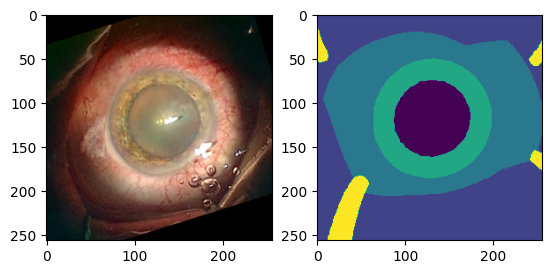

mask torch.Size([256, 256]) torch.uint8 (array([0, 1, 2, 3, 5], dtype=uint8), array([ 5882, 26547, 21969,  8572,  2566]))


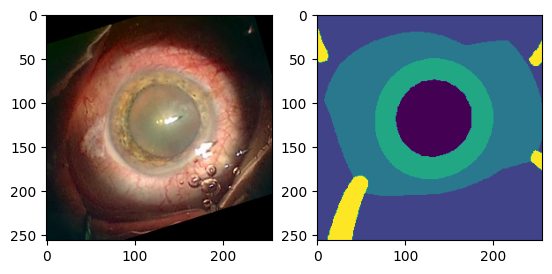

mask torch.Size([256, 256]) torch.uint8 (array([0, 1, 2, 3, 5], dtype=uint8), array([ 5940, 26602, 21855,  8562,  2577]))


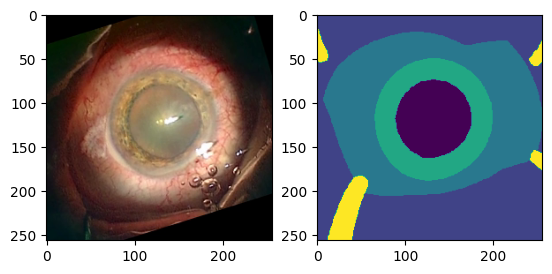

In [19]:
for i, batch in enumerate(train_dataset2):

    if i == 1:
        break
    else:

        print(batch.keys())
        print(batch["image"].shape)
        print(batch["mask"].shape)
        print(batch["video_name"])

        image = batch["image"]
        mask = batch["mask"]


        print("image", image.shape, image.dtype, torch.min(image), torch.max(image))
        print("mask", image.shape, image.dtype, np.unique(mask.numpy(), return_counts=1))


        for j in range(3):

            print("mask", mask[j].shape, mask[j].dtype, np.unique(mask[j].numpy(), return_counts=1))
            
            img = image[j].permute(1,2,0).numpy().astype(np.float32)

            plt.figure()
            plt.subplot(121)
            plt.imshow(img)
            plt.subplot(122)
            plt.imshow(mask[j])

            plt.show()

In [40]:
import torch
import random
from torch.utils.data import DataLoader, ConcatDataset, Sampler

class BalancedBatchSampler(Sampler):
    def __init__(self, dataset_A_len, dataset_B_len, batch_size=4):
        self.dataset_A_len = dataset_A_len
        self.dataset_B_len = dataset_B_len
        self.batch_size = batch_size
        self.half_batch = batch_size // 2
        
        # Calculate how many batches make an epoch. 
        # Using max() ensures we see all data from the larger dataset, 
        # while the smaller dataset will loop over.
        self.num_batches = max(dataset_A_len, dataset_B_len) // self.half_batch

    def __iter__(self):
        # ConcatDataset stacks B after A. 
        # So A's indices are 0 to len(A)-1
        # B's indices are len(A) to len(A)+len(B)-1
        indices_A = list(range(self.dataset_A_len))
        indices_B = list(range(self.dataset_A_len, self.dataset_A_len + self.dataset_B_len))

        # Shuffle indices for this epoch
        random.shuffle(indices_A)
        random.shuffle(indices_B)

        # print(indices_A,indices_B)

        for i in range(self.num_batches):
            # Select 2 items from A and 2 from B.
            # The modulo (%) ensures we loop safely if one dataset is smaller.
            batch_A = [indices_A[(i * self.half_batch + j) % self.dataset_A_len] for j in range(self.half_batch)]
            batch_B = [indices_B[(i * self.half_batch + j) % self.dataset_B_len] for j in range(self.half_batch)]

            print(batch_A, batch_B)
            
            # Combine to make a batch of 4
            batch = batch_A + batch_B
            
            # Optional: Shuffle the batch so the model doesn't always see A first, then B
            random.shuffle(batch) 
            
            yield batch

    def __len__(self):
        return self.num_batches







In [4]:

sim_to_cataract_swomo = {
    0:2,
    1:0, 
    2:0,
    3:1,
    5:0,
    6:5,
}

# sim_to_cataract_swomo_map = dict((v,k) for k,v in sim_to_cataract_swomo.items())


def sim_to_cataract_swomo_fun(input):


    input = input.astype(np.uint8)

    output = np.arange(256, dtype=np.uint8)
    for k, v in sim_to_cataract_swomo.items():
        output[k] = v
    return output[input]


In [21]:
train_dataset1 = DatasetRetinaVideoBatches(df_path = "/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/dataset_info/training_batch_paths/paths_train_batches_21_frames_classes_0,1,2_testing.csv")

train_dataset2 = DatasetRetinaGIGVideo(video_path = "/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset5", mask_mode = "sim_to_swomo")


Loaded 424 samples
Loaded 424 video samples


424 424
848
[363, 111, 178, 317, 12, 30, 329, 259, 275, 239, 173, 195, 137, 372, 320, 364, 20, 129, 48, 32, 242, 289, 106, 269, 200, 209, 205, 234, 203, 46, 350, 313, 131, 201, 248, 354, 198, 3, 66, 327, 223, 213, 13, 332, 393, 23, 58, 27, 186, 221, 84, 246, 312, 45, 140, 336, 69, 306, 165, 226, 113, 397, 38, 360, 192, 76, 331, 42, 230, 333, 11, 307, 382, 73, 56, 279, 177, 284, 94, 77, 138, 162, 82, 118, 398, 402, 263, 268, 132, 172, 141, 179, 1, 352, 92, 168, 153, 109, 286, 375, 339, 5, 419, 185, 324, 87, 89, 136, 83, 297, 334, 31, 403, 349, 157, 407, 346, 381, 10, 305, 255, 316, 308, 182, 70, 90, 39, 211, 107, 270, 232, 261, 299, 150, 124, 326, 290, 278, 357, 347, 207, 55, 67, 41, 405, 79, 304, 395, 81, 415, 142, 190, 283, 231, 271, 6, 267, 412, 21, 311, 406, 220, 154, 399, 296, 206, 68, 78, 103, 149, 180, 281, 199, 155, 323, 396, 389, 228, 176, 251, 380, 387, 148, 388, 193, 386, 52, 340, 93, 65, 374, 99, 233, 127, 276, 35, 196, 75, 243, 285, 91, 194, 417, 102, 147, 139, 235, 125, 31

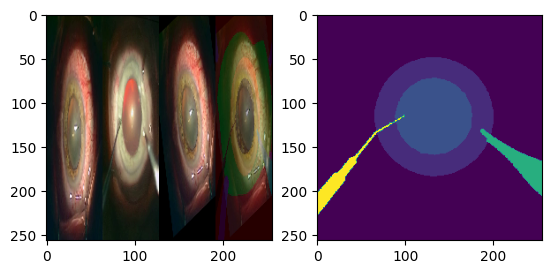

BATCH  1


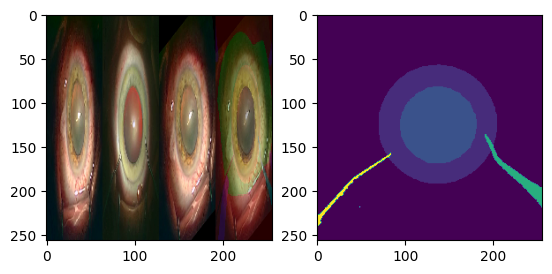

BATCH  2


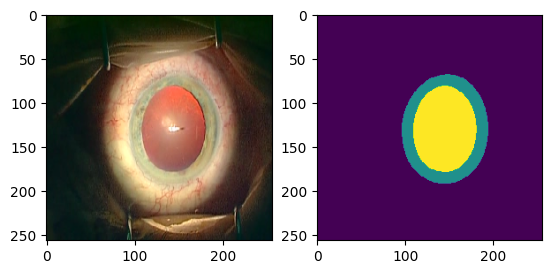

BATCH  3


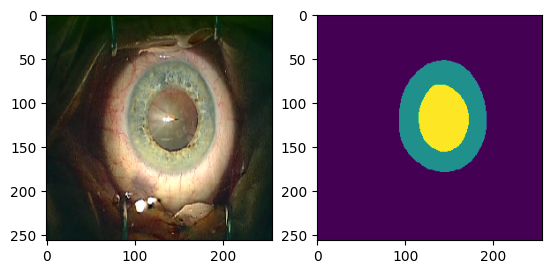

[48, 32] [643, 442]


In [22]:

print(len(train_dataset1), len(train_dataset2))

# 1. Concatenate the datasets
combined_dataset = ConcatDataset([train_dataset1, train_dataset2])
print(len(combined_dataset))

# 2. Create the custom sampler
balanced_sampler = BalancedBatchSampler(len(train_dataset1), len(train_dataset2), batch_size=4)

# 3. Create the DataLoader
# Note: You cannot use `shuffle=True` or `batch_size` here because 
# the custom `batch_sampler` is handling both of those parameters now.
dataloader = DataLoader(
    combined_dataset, 
    batch_sampler=balanced_sampler,
    num_workers=4
)

# 4. Standard Training Loop
for i, batch in enumerate(dataloader):

    if i == 1:
        break
    # `batch` now has a shape of 4, guaranteed to be 2 from A and 2 from B.
    print(batch['image'].shape)
    print(batch['mask'].shape)

    image = batch['image']
    mask = batch['mask']

    for b in range(4):
        print("BATCH ",b)

        for j in range(1):

            img = image[b,j].permute(1,2,0).numpy().astype(np.float32)

            plt.figure()
            plt.subplot(121)
            plt.imshow(img)
            plt.subplot(122)
            plt.imshow(mask[b, j])

            plt.show()

# Dataset for GiG dataset with flows/depths from original simulation videos

In [9]:
from my_datasets import DatasetRetinaVideoBatches, DatasetRetinaGIGVideo


In [11]:
train_dataset1 = DatasetRetinaVideoBatches(df_path = "/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/dataset_info/training_batch_paths/paths_train_batches_21_frames_classes_0,1,2.csv")

train_dataset2 = DatasetRetinaGIGVideo(video_path = "/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset_keyth_004_mth_03", limit = 501, mask_mode = "sim_to_swomo")


Loaded 501 samples
Loaded 1333 video samples
Loaded 1333 flows samples
Loaded 1333 depths samples
After limit
Loaded 501 video samples
Loaded 501 flows samples
Loaded 501 depths samples


4 4
8
/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/videos/real_case_2000_0000000809_sim_name_r2_frame_0002-0022.mp4/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/videos/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.mp4/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/videos/real_case_2000_0000000961_sim_name_r2_frame_0002-0022.mp4   /home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/flows/real_case_2000_0000000809_sim_name_r2_frame_0002-0022.npy/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/flows/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.npy/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/flows/real_case_2000_0000000961_sim_name_r2_frame_0002-0022.npy   /home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset6_flows/depth/real_case_2000_0000000144_sim_name_r2_frame_0002-0022.npy/home/MichalMo/projects/SurgSora/Training/GIG_dataset/dataset

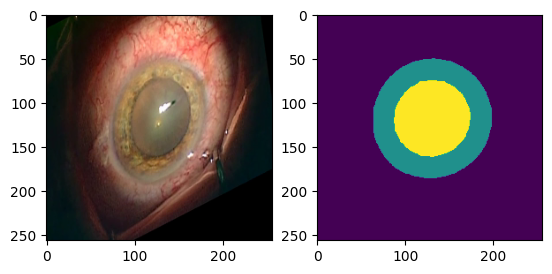

BATCH  1


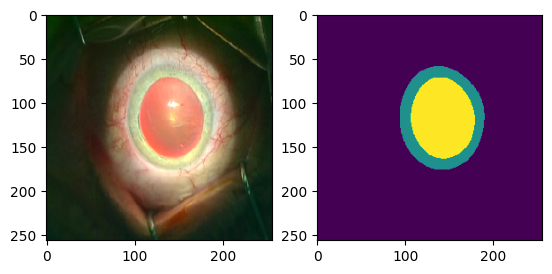

In [34]:

print(len(train_dataset1), len(train_dataset2))

# 1. Concatenate the datasets
combined_dataset = ConcatDataset([train_dataset1, train_dataset2])
print(len(combined_dataset))

# 2. Create the custom sampler
balanced_sampler = BalancedBatchSampler(len(train_dataset1), len(train_dataset2), batch_size=2)

# 3. Create the DataLoader
# Note: You cannot use `shuffle=True` or `batch_size` here because 
# the custom `batch_sampler` is handling both of those parameters now.
dataloader = DataLoader(
    combined_dataset, 
    batch_sampler=balanced_sampler,
    num_workers=4
)


# dataloader = DataLoader(
#     train_dataset2, 

# )

# 4. Standard Training Loop
for i, batch in enumerate(dataloader):

    if i == 1:
        break
    # `batch` now has a shape of 4, guaranteed to be 2 from A and 2 from B.
    print(batch['image'].shape)
    print(batch['mask'].shape)

    image = batch['image']
    mask = batch['mask']
    flows = batch["flows"]
    depths = batch["depths"]

    # for fit, f in enumerate(flows):
    #     if not f:
    #         flows[fit] = 
    for f in flows:
        print(f.shape, torch.max(f))

    for f in depths:
        print("d", f.shape, torch.max(f))

    for b in range(image.shape[0]):
        print("BATCH ",b)

        for j in range(1):

            img = image[b,j].permute(1,2,0).numpy().astype(np.float32)

            plt.figure()
            plt.subplot(121)
            plt.imshow(img)
            plt.subplot(122)
            plt.imshow(mask[b, j])

            plt.show()

In [5]:
from natsort import natsorted


class DatasetSWoMoVideo(Dataset):
    def __init__(self, main_path, image_size = 256,  augment = False, 
                    n_frames = 21,
                    augmentation_factor = 1,             
                    overlap_size=21,
                    frame_stride=1):
        self.data = []


        self.main_path = main_path
        self.image_shape = (image_size, image_size)
        self.n_frames = n_frames



        # ])

        split_mode = "train"
        video_txt = os.path.join(main_path, "splits", split_mode+".txt")
        print(video_txt)

        self.video_list = []
        with open(video_txt, "r") as f:
            self.video_list.extend([os.path.join(os.path.dirname(os.path.dirname(video_txt)), "video_frames_jpg", x) for x in f.read().splitlines()])

        print(len(self.video_list))
        print(self.video_list[0])

        self.class_size = 15


        self.sample = []
        for video in self.video_list:
            # print(video)
            frame_path = video
            segm_path = video.replace("video_frames_jpg", "masks_sim")

            frame_list = natsorted(glob.glob(frame_path + "/*.jpg"))[::frame_stride]
            frame_list = [os.path.basename(x) for x in frame_list]
            segm_list = natsorted(glob.glob(segm_path + "/*.png"))[::frame_stride]


            for n in range(0, len(frame_list), overlap_size):
                if n + self.n_frames + 1 < len(frame_list):
                    self.sample.append({"video": os.path.basename(video),
                                        "video_folder": os.path.dirname(os.path.dirname(video)),
                                        "frame": frame_list[n:n + self.n_frames + 1], # Adding one for optical flow info for graph construction under augmentation
                                        "segm": segm_list[n:n + self.n_frames + 1]}) 


        # print(f"Loaded {len(self.image_numbers)} samples, will virtually expand ×{augmentation_factor} = {len(self.image_numbers) * augmentation_factor}")


    def __len__(self):
        return len(self.image_numbers) * self.augmentation_factor

    # def __getitem__(self, idx):
    #     base_idx = idx % len(self.df)
    #     item = self.df.iloc[base_idx]


    #     image_path = item['image_path']
    #     target_path = item['mask_path']
    #     prompt = item['text']


    #     image = Image.open(image_path)
    #     mask = cv2.imread(target_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale

    #     if self.augment:
    #         augmented = self.aug(image=np.asarray(image), mask=np.asarray(mask))
    #         image = augmented['image']
    #         mask = augmented['mask']

    #     image = np.asarray(image)
    #     mask = np.asarray(mask)

    #     # image = self.image_trans(image).numpy().astype(np.float32).transpose(1,2,0)

    #     # _, mask = self.mask_trans(image=image, mask=mask).values()


    #     segmentation = np.eye(14)[mask].astype(np.float32) #.transpose(2,0,1)

    #     image = image.astype(np.float16)
    #     segmentation = segmentation.astype(np.float16)


    #     # print(image.shape, segmentation.shape)
    #     image = image.transpose(2,0,1)
    #     segmentation = segmentation.transpose(2,0,1)
    #     # print(image.shape, segmentation.shape)

    #     # return dict(jpg=image, txt=prompt, hint=segmentation)


    #     # image = np.ones([3,256,256], dtype=np.float16)
    #     # segmentation = np.ones([14, 256,256], dtype=np.float16)


    #     # image = np.ones([3,256,256], dtype=np.float16)
    #     # segmentation = np.ones([14,256,256], dtype=np.float16)

    #     # print("image_path ", image_path)

    #     # print("prompt", prompt, type(prompt))
    #     return dict(image=torch.tensor(image), text=prompt, mask=torch.tensor(segmentation), file_name=image_path)

    def __getitem__(self, index):
        items = {}
        frames = []
        graphs = []
        segmentations = []
        cond_videos = []
        class_labels = []
        sequence = self.sample[index]




        for idx in range(self.n_frames): 
            
            image = os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][idx])
            image = np.array(Image.open(image).convert("RGB"))
            segmentation = np.array(Image.open(sequence['segm'][idx]))


            image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)
            segmentation = cv2.resize(segmentation, self.image_shape, interpolation=cv2.INTER_NEAREST)

            image = image.astype(np.float32)
            image = torch.from_numpy(image).permute(2, 0, 1)
            frames.append(image)

            segmentation = torch.from_numpy(segmentation.astype(np.int64))

            class_label = torch.zeros(self.class_size, dtype=torch.int64)
            class_label[segmentation.unique().long()] = 1
            class_labels.append(class_label)

            # print(segmentation.shape)
            
            # segmentation = F.one_hot(segmentation, num_classes=self.class_size)
            segmentation = segmentation.to(dtype=torch.float32)
            segmentations.append(segmentation)

        items["image"] = torch.stack(frames)
        items["class_label"] = torch.max(torch.stack(class_labels), dim=0).values
        items["mask"] = torch.stack(segmentations)
        items["all_frame_path"] = [os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"][i]) for i in range(self.n_frames)]
        # items["text"] = self.text

        return items

        


In [6]:

class DatasetSWoMo2D(Dataset):

    # For 2D Training

    def __init__(self, main_path, image_size = 256,  augment = False):
        self.data = []


        self.main_path = main_path
        self.image_shape = (image_size, image_size)



        # ])

        split_mode = "train"
        video_txt = os.path.join(main_path, "splits", split_mode+".txt")
        print(video_txt)

        self.video_list = []
        with open(video_txt, "r") as f:
            self.video_list.extend([os.path.join(os.path.dirname(os.path.dirname(video_txt)), "video_frames_jpg", x) for x in f.read().splitlines()])

        print(len(self.video_list))
        print(self.video_list[0])

        self.class_size = 15


        self.sample = []
        for video in self.video_list:
            # print(video)
            frame_path = video
            segm_path = video.replace("video_frames_jpg", "masks_sim")

            frame_list = natsorted(glob.glob(frame_path + "/*.jpg"))
            frame_list = [os.path.basename(x) for x in frame_list]
            segm_list = natsorted(glob.glob(segm_path + "/*.png"))


            for n in range(0, len(frame_list)):
                self.sample.append({"video": os.path.basename(video),
                                    "video_folder": os.path.dirname(os.path.dirname(video)),
                                    "frame": frame_list[n], # Adding one for optical flow info for graph construction under augmentation
                                    "segm": segm_list[n]}) 


        # print(f"Loaded {len(self.image_numbers)} samples, will virtually expand ×{augmentation_factor} = {len(self.image_numbers) * augmentation_factor}")


    def __len__(self):
        return len(self.image_numbers) * self.augmentation_factor


    def __getitem__(self, index):
        items = {}
        frames = []
        graphs = []
        segmentations = []
        cond_videos = []
        class_labels = []
        sequence = self.sample[index]




            
        image = os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"])
        image = np.array(Image.open(image).convert("RGB"))
        segmentation = np.array(Image.open(sequence['segm']))


        image = cv2.resize(image, self.image_shape, interpolation=cv2.INTER_NEAREST)
        segmentation = cv2.resize(segmentation, self.image_shape, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32)
        image = torch.from_numpy(image).permute(2, 0, 1)
        frames.append(image)

        segmentation = torch.from_numpy(segmentation.astype(np.int64))

        class_label = torch.zeros(self.class_size, dtype=torch.int64)
        class_label[segmentation.unique().long()] = 1
        class_labels.append(class_label)

        # print(segmentation.shape)
        
        # segmentation = F.one_hot(segmentation, num_classes=self.class_size)
        segmentation = segmentation.to(dtype=torch.float32)
        segmentations.append(segmentation)

        items["image"] = torch.stack(frames)
        items["class_label"] = torch.max(torch.stack(class_labels), dim=0).values
        items["mask"] = torch.stack(segmentations)
        items["all_frame_path"] = os.path.join(sequence["video_folder"], "video_frames_jpg", sequence["video"], sequence["frame"])
        # items["text"] = self.text

        return items


In [7]:
main_path = "/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K"
train_dataset1 = DatasetSWoMo2D(main_path = main_path)

/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/splits/train.txt
2
/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000


In [8]:
len(train_dataset1.sample)

3272

In [9]:
train_dataset1.sample[1]

{'video': 'case_2000',
 'video_folder': '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K',
 'frame': '0000000001.jpg',
 'segm': '/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/masks_sim/case_2000/0000000001.png'}

In [10]:
b1 = train_dataset1.__getitem__(1)
b1.keys()

dict_keys(['image', 'class_label', 'mask', 'all_frame_path'])

In [11]:
b1["all_frame_path"]

'/home/MichalMo/projects/SurgSora/SWoMo/datasets/Cataract-1K/video_frames_jpg/case_2000/0000000001.jpg'

In [12]:
b1["mask"].shape

torch.Size([1, 256, 256])

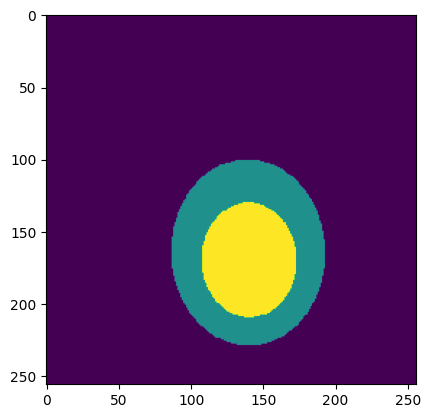

In [13]:
plt.imshow(b1["mask"][0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


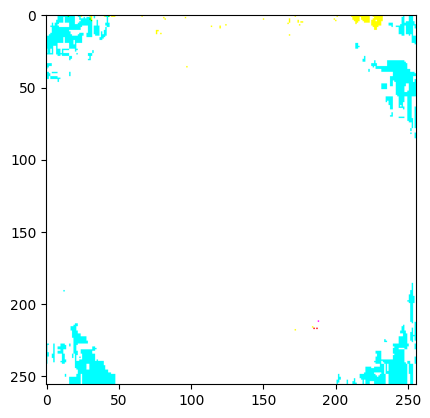

In [14]:
plt.imshow(b1["image"][0].permute(1,2,0))